<a href="https://colab.research.google.com/github/Tdaniels4real/music-popularity-capstone/blob/main/music_popularity_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Music Popularity Capstone

**Group name:** Group 7  |  **Your genre:** Afrobeat  |  **Date:** September 2026

---
## Part 1 — Load the data
**Weeks 1–2**

##### TASK 1.1: IMPORT LIBRARIES

Let's bring in all the tools we need for the whole project.

* **pandas** = for handling data
* **numpy** = for doing math
* **matplotlib/seaborn** = for making charts

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
print('Ready')

Ready


##### TASK 1.2: YOUR GENRE

We chose **afrobeat** as our genre. Let's set that up. We will also pick a number to keep our random steps the same every time we run the code.

In [5]:
# Tell the notebook what our genre is
GENRE = 'afrobeat'

# Pick a number to keep our random steps the same
RANDOM_STATE = 42

print(f'Working on: {GENRE}')

Working on: afrobeat


##### TASK 1.3: READ THE FILE
In order to read the spotify_tracks.csv, we needed to upload the file into the colab environment ( first cell beneath), after which we were able to read it (second cell).

In [6]:

df = pd.read_csv('spotify_tracks.csv') # this allowed us to load the spotify_tracks.csv

print('Rows:', df.shape[0]) # prints the number of rows as Rows: number of rows
print('Columns:', df.shape[1]) # prints the number of columns as Columns: number of columns
df.head() # shows the first 5 rows including the heading

Rows: 17643
Columns: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,False,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,False,0.420,0.1660,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,False,0.438,0.3590,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933.0,False,0.266,0.0596,0.0,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853.0,False,0.618,0.4430,2.0,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


##### TASK 1.4: FIRST LOOK AT THE DATA

Three questions we always ask:
1. What columns do we have?
2. What is missing?
3. What do the numbers look like?

In [7]:
# What columns do we have?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17643 entries, 0 to 17642
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17643 non-null  int64  
 1   track_id          17643 non-null  object 
 2   artists           17643 non-null  object 
 3   album_name        17643 non-null  object 
 4   track_name        17642 non-null  object 
 5   popularity        17642 non-null  float64
 6   duration_ms       17642 non-null  float64
 7   explicit          17642 non-null  object 
 8   danceability      17642 non-null  float64
 9   energy            17642 non-null  float64
 10  key               17642 non-null  float64
 11  loudness          17642 non-null  float64
 12  mode              17642 non-null  float64
 13  speechiness       17642 non-null  float64
 14  acousticness      17642 non-null  float64
 15  instrumentalness  17642 non-null  float64
 16  liveness          17642 non-null  float6

In [8]:
# What is missing?
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,1
popularity,1
duration_ms,1
explicit,1
danceability,1
energy,1


In [9]:
# What do the numbers look like?
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,17643.000000,17642.000000,1.764200e+04,17642.000000,17642.000000,17642.000000,17642.000000,17642.000000,17642.000000,17642.00000,17642.000000,17642.000000,17642.000000,17642.000000,17642.000000
mean,8821.000000,32.802914,2.385319e+05,0.555609,0.582111,5.311189,-9.533904,0.664664,0.069471,0.37066,0.232542,0.192700,0.467661,121.265151,3.891679
std,5093.239735,21.659387,1.413564e+05,0.181560,0.272656,3.563188,5.746593,0.472121,0.073102,0.35935,0.358380,0.168277,0.267486,29.144801,0.426836
min,0.000000,0.000000,1.745300e+04,0.000000,0.000756,0.000000,-41.808000,0.000000,0.000000,0.00000,0.000000,0.011600,0.000000,0.000000,0.000000
25%,4410.500000,16.000000,1.731470e+05,0.437000,0.373000,2.000000,-11.483000,0.000000,0.034100,0.01640,0.000000,0.095300,0.241000,99.963000,4.000000
50%,8821.000000,33.000000,2.212290e+05,0.570000,0.609000,5.000000,-8.012000,1.000000,0.044500,0.25600,0.000712,0.123000,0.449000,121.689000,4.000000
75%,13231.500000,50.000000,2.759682e+05,0.689000,0.824750,9.000000,-5.735250,1.000000,0.069400,0.72100,0.496000,0.237000,0.685000,139.324500,4.000000
max,17642.000000,93.000000,4.789026e+06,0.981000,1.000000,11.000000,4.532000,1.000000,0.943000,0.99600,0.995000,0.995000,0.995000,243.372000,5.000000


##### TASK 1.5: CHECK IF OUR GENRE EXISTS

Before we filter out all the other music, we need to double-check that our chosen genre actually exists in the dataset. We are going to look through the list of genres to make sure "afrobeat" is in there and check exactly how it is spelled.

In [10]:
# Display all unique genre values to verify formatting and spelling
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', nan], dtype=object)

In [11]:
# Check total number of unique genres in the dataset
df['track_genre'].nunique()

18

In [12]:
print('Is your genre there?', GENRE in df['track_genre'].unique())

Is your genre there? True


##### TASK 1.6: FILTER YOUR GENRE

The original dataset contains tracks from many different genres. Since the genre we chose is Afrobeat, we filter the dataset to keep only the tracks where the genre is equal to "afrobeat".

This ensures that all of our analysis and cleaning from here on out is completely specific to our chosen genre.

In [13]:
df = df[df['track_genre'] == GENRE].copy()

print(f'{len(df)} tracks in {GENRE}')
df[['track_name', 'artists', 'popularity']].head()

1000 tracks in afrobeat


,track_name,artists,popularity
1000,Jireh (My Provider),Limoblaze;Lecrae;Happi,64.0
1001,Ainda Há Tempo,Criolo,44.0
1002,Fellini,Criolo,42.0
1003,Lion Man,Criolo,46.0
1004,Espiral de Ilusão,Criolo,44.0


In [14]:
#shows the first five rows with afrobeat
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1000,1000,4pR4oQJULf7FDB54TleMyH,Limoblaze;Lecrae;Happi,Jireh (My Provider),Jireh (My Provider),64.0,168000.0,False,0.443,0.778,0.0,-7.564,0.0,0.2660,0.241,0.000000,0.2150,0.628,128.250,5.0,afrobeat
1001,1001,4Ds4bq6aqOSAp1T7DikOi4,Criolo,Ainda Há Tempo,Ainda Há Tempo,44.0,318360.0,False,0.580,0.800,6.0,-7.528,1.0,0.3450,0.281,0.000000,0.0708,0.483,81.303,4.0,afrobeat
1002,1002,7nYbKsvhM88mHCmFsAIQVp,Criolo,Fellini,Fellini,42.0,171989.0,False,0.805,0.746,1.0,-5.211,0.0,0.1850,0.238,0.000000,0.2150,0.717,127.922,4.0,afrobeat
1003,1003,7gVNP7rI9UBZndge0ulKfL,Criolo,Nó na Orelha,Lion Man,46.0,205440.0,False,0.582,0.660,7.0,-4.988,0.0,0.0544,0.399,0.000000,0.1270,0.484,83.789,4.0,afrobeat
1004,1004,1hLvWelTny8vttEEZIXVjw,Criolo,Espiral de Ilusão,Espiral de Ilusão,44.0,220800.0,False,0.776,0.314,2.0,-9.513,1.0,0.0340,0.881,0.000723,0.1390,0.476,124.055,4.0,afrobeat


##### TASK 1.7: THREE OBSERVATIONS

We make three observations from the afrobeat dataset after running summary statistics on popularity and danceability.

We perform descriptive (summary) statistics on popularity and danceability.
Popularity tells us how played the tracks are (0-100).
Danceability tells us how suitable the tracks are for dancing (0-1).

In [15]:
# Summary statistics for afrobeat popularity and danceability
df[['popularity', 'danceability']].describe()

,popularity,danceability
count,1000.000000,1000.00000
mean,24.399000,0.66958
std,10.512579,0.12384
min,0.000000,0.28500
25%,18.000000,0.58300
50%,21.000000,0.69100
75%,28.000000,0.76225
max,75.000000,0.97400


#### Our Three Observations

**1. The lowest popularity score is 0.**
The minimum popularity score in our afrobeat dataset is 0 out of 100. This means some afrobeat tracks in our data have had little or no plays at all, showing that the genre includes both well-known and completely unknown tracks.

**2. The highest popularity score is 75.**
The maximum popularity score in our afrobeat dataset is 75 out of 100. No afrobeat track in our data reaches the maximum possible score of 100, suggesting these tracks are well-played but not globally chart-topping.

**3. Average danceability is 0.67.**
The mean danceability score for afrobeat tracks is 0.67 on a 0-to-1 scale. This is well above the midpoint of 0.5, confirming that afrobeat is a highly danceable genre.

---
## Part 2” Clean the data
**Week 3**

Before we can start finding patterns in our music, we need to make sure our dataset is perfectly clean and ready to go.

In Week 3, we will look for and fix any messy parts of our data. This includes throwing away junk columns we don't need, removing duplicate songs, and deleting any rows with missing information.

##### TASK 2.1: DROP THE JUNK COLUMN

When we loaded our music data, an extra column called `Unnamed: 0` sneaked in. This happens because the original file had an empty column name for its row numbers.

Since this column doesn't contain any real music data, it is basically just junk taking up space. So, we are going to drop it from our dataset.

In [16]:
# Count columns before
initial_count = len(df.columns)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Count the difference
dropped_count = initial_count - len(df.columns)
print(f"Number of columns dropped: {dropped_count}")
print(list(df.columns))

Number of columns dropped: 1
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


##### TASK 2.2: REMOVE DUPLICATE TRACKS

Sometimes the exact same song gets recorded in the dataset multiple times. If we leave them in, it will mess up our analysis by counting the same track twice.

We are going to check for any tracks that have the exact same `track_id` and drop the extras.

In [17]:
# Check how many duplicates we have
print('Duplicate tracks:', df.duplicated(subset='track_id').sum())

# Inspect duplicate records before deletion
# By setting keep=False, it shows us both the original and the copy side-by-side
duplicates = df[df.duplicated(subset='track_id', keep=False)].sort_values('track_name')
display(duplicates[['track_id', 'track_name', 'artists']].head())

# Drop them
df = df.drop_duplicates(subset='track_id')

# See how many tracks are left
print('Tracks left:', len(df))

Duplicate tracks: 1


,track_id,track_name,artists
1874,0CDucx9lKxuCZplLXUz0iX,Song for Rollins,Buena Onda Reggae Club
1925,0CDucx9lKxuCZplLXUz0iX,Song for Rollins,Buena Onda Reggae Club


Tracks left: 999


##### TASK 2.3: DELETE MISSING VALUES

Our models cannot learn from empty data. We need to check if any of our tracks are missing important information like their name, artist, or audio features.

If we find any tracks with missing data, we will drop them from the dataset to keep things clean.

In [18]:
# Check what is missing before we clean it
print('Missing before:')
print(df.isna().sum()[df.isna().sum() > 0])

# Calculate the percentage of missing data across the entire dataset
total_missing = df.isna().sum().sum()
total_cells = np.prod(df.shape)
percent_missing = (total_missing / total_cells) * 100
print(f"\nWe are missing {round(percent_missing, 2)}% of our total data.")

# Drop any row that has missing data
df = df.dropna()

# Check if it worked
print('\nMissing after:', df.isna().sum().sum())
print('Tracks left:', len(df))

Missing before:
Series([], dtype: int64)

We are missing 0.0% of our total data.

Missing after: 0
Tracks left: 999


##### TASK 2.4: CONVERT THE DURATION

Right now, the length of our songs is stored in **milliseconds**. A number like 300,000 milliseconds is really hard for a human to imagine.

We are going to convert that column into standard minutes so that we can easily see exactly how long our average song is.

In [19]:
# Create a new column by converting milliseconds into minutes
df['duration_min'] = df['duration_ms'] / 60000

# Print the summary statistics rounded to 2 decimal places
print(df['duration_min'].describe().round(2))

# Drop the original milliseconds column to optimize memory usage
if 'duration_ms' in df.columns:
    df = df.drop(columns=['duration_ms'])
    print("\nDropped the old duration_ms column to save memory.")

count    999.00
mean       4.14
std        1.58
min        0.53
25%        3.24
50%        3.85
75%        4.59
max       13.81
Name: duration_min, dtype: float64

Dropped the old duration_ms column to save memory.


#####TASK 2.5: LOOK AT ODD VALUES
 Look at unusual values (like tracks with 0 popularity or very short length) before deciding whether to remove them.

In [20]:
# Some tracks have popularity 0 or are very short
# Look before you delete anything

print('Tracks with popularity 0:', (df['popularity'] == 0).sum())
print()
print('Shortest tracks:')
print(df.nsmallest(5, 'duration_min')[['track_name', 'duration_min', 'popularity']])

Tracks with popularity 0: 15

Shortest tracks:
              track_name  duration_min  popularity
1735                Caju      0.530400        18.0
1574  Canoeiro (vinheta)      0.600100        19.0
1263         Cool Love 3      0.628367        25.0
1987          Goldmember      0.963100        18.0
1807               Omega      1.078217        19.0


##### TASK 2.6: CREATE THE HIT LABEL



In [21]:
# Create a new column 'is_hit': 1 if above median, 0 if below
# This will be our target for Part 5 (classification)

median_pop = df['popularity'].median()
df['is_hit'] = (df['popularity'] > median_pop).astype(int)

print(f'Median popularity in {GENRE}: {median_pop:.0f}')
print(df['is_hit'].value_counts())

Median popularity in afrobeat: 21
is_hit
0    551
1    448
Name: count, dtype: int64


#####CLEANING LOG

| Step | What we found | What we did | Why |
|------|---------------|-------------|-----|
| Junk column | Unnamed: 0 column | Dropped it | No useful information |
| Duplicates | 1 duplicate track_id | Dropped it | Avoid double-counting |
| Missing values | 0 missing values | No action needed | Data was already clean |
| Odd values | 15 tracks with popularity 0 | Kept them | Real tracks, not errors |
| New columns | duration_min added | Converted ms to minutes | Easier to read |
| New columns | is_hit added | Split at median (21) | Target for Part 5 |

##Part 3 - Explore The Data

#####TASK 4.1:
Chart 1 - Who dominates your genre?






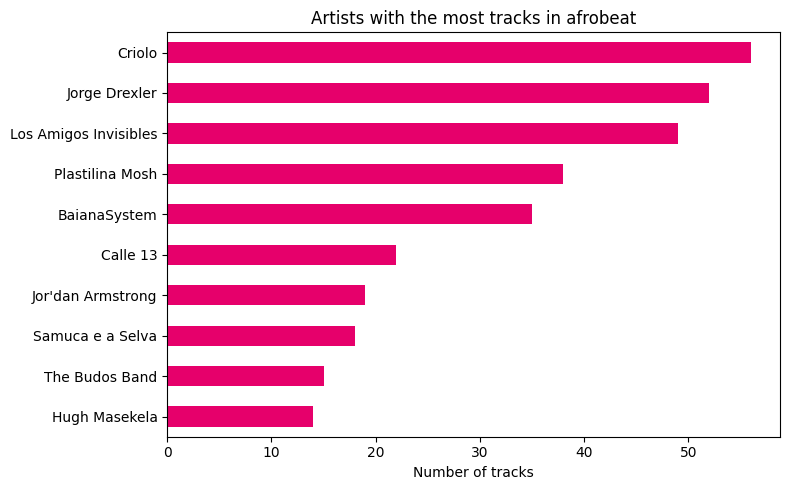

In [22]:
top = df['artists'].value_counts().head(10)

plt.figure(figsize=(8, 5))
top.sort_values().plot(kind='barh', color='#E6006B')
plt.title(f'Artists with the most tracks in {GENRE}')
plt.xlabel('Number of tracks')
plt.ylabel('')
plt.tight_layout()
plt.show()

**What this shows:**
The afrobeat genre in our dataset is dominated by a small group of artists. Criolo leads with more than 50 tracks nearly four times more than the 10th artist. There is a noticeable gap between the top five artists (about 35–56 tracks).

#####TASK 4.2: Chart 2 - How Popular is your genre?

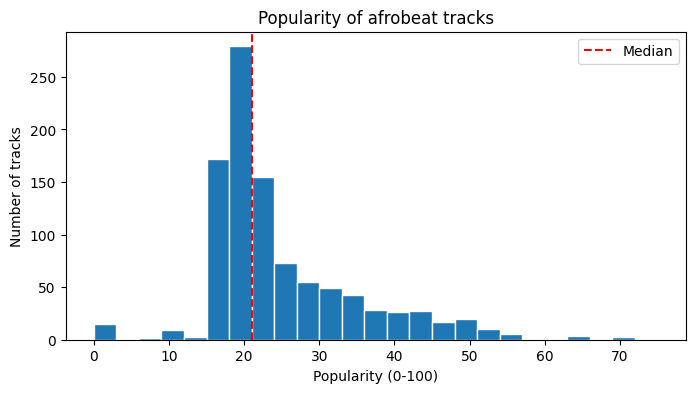

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(df['popularity'], bins=25, edgecolor='white')
plt.axvline(df['popularity'].median(), color='red', linestyle='--', label='Median')
plt.title(f'Popularity of {GENRE} tracks')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Number of tracks')
plt.legend()
plt.show()

**What this shows:**
Most afrobeat tracks in our dataset have low popularity. The distribution peaks around 20 out of 100, with the median at 21, meaning half of all tracks score 21 or below. Very few tracks reach above 50, and there is a small spike at 0 (tracks that have never been played). This suggests afrobeat in our dataset is a "long tail" genre a few standout tracks, with most others remaining relatively unknown.